In [1]:
%matplotlib ipympl

In [37]:
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats.mstats import winsorize
import pandas as pd

In [3]:
start = date(2020, 7, 1)
end = date(2026, 5, 31)

In [4]:
client = ModoEnergyAPIClient(cache_requests=True)

In [5]:
prices = client.get_ercot_prices(date_from=start, date_to=end)

Fetching pages : 0page [00:00, ?page/s]

In [6]:
houston_prices = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
]

<Axes: xlabel='deliveryDate'>

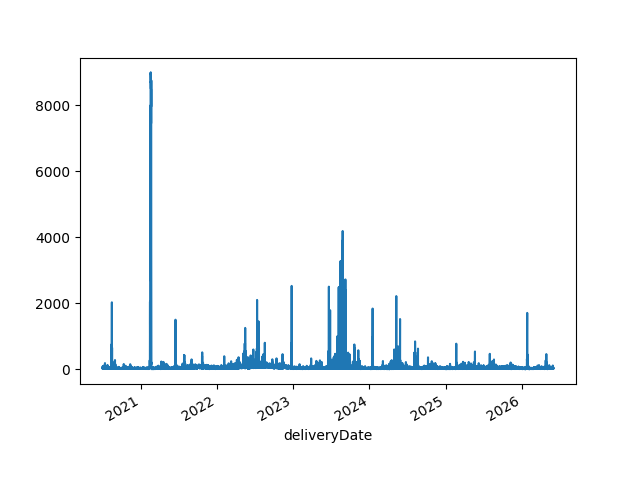

In [36]:
houston_prices.plot()

In [38]:
winsorized = pd.DataFrame(
    {houston_prices.name: winsorize(houston_prices, limits=[None, 0.01])},
    index=houston_prices.index,
)

<Axes: xlabel='deliveryDate'>

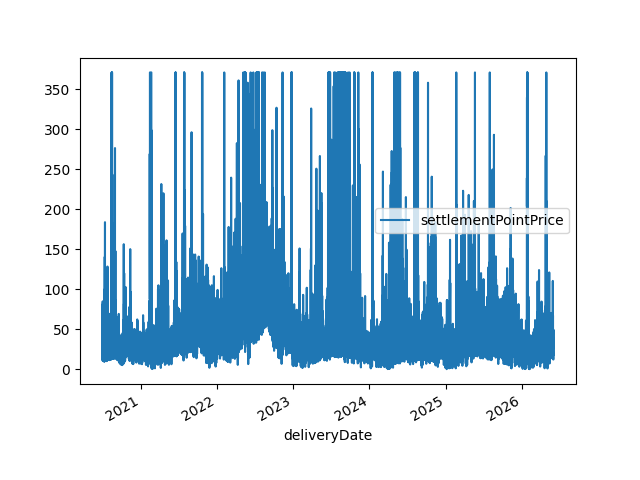

In [39]:
winsorized.plot()

In [41]:
fs = 1.0  # / 168.0
frequencies, psd = periodogram(winsorized, fs=fs, scaling="spectrum")

In [43]:
psd

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(51864, 1))

In [42]:
valid_idx = frequencies > 0
frequencies = frequencies[valid_idx]
psd = psd[valid_idx]

# Step 4: Detect all notable peaks
# Adjust 'prominence' or 'height' based on your data's noise level
peaks, properties = signal.find_peaks(psd, prominence=np.max(psd) * 0.05)

# Step 5: Translate peaks into time periods
print("Detected Unknown Seasonalities:")
print("-" * 40)
for peak in peaks:
    freq_per_hour = frequencies[peak]
    period_hours = 1.0 / freq_per_hour
    period_days = period_hours / 24.0
    period_weeks = period_days / 7.0
    power = psd[peak]

    print(f"Cycle Found! Power: {power:.2f}")
    print(f"  -> Hours: {period_hours:.1f}")
    print(f"  -> Days:  {period_days:.1f}")
    print(f"  -> Weeks: {period_weeks:.2f}\n")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 51864 but size of corresponding boolean axis is 1